# 🎮 VCT 2025 Champions — Complete Data Analysis & Interactive Dashboard

**Dataset Source:** Kaggle — VCT 2025 Champions  
**Author:** Prasanth Sundar  
**Topics Covered:**
- Kills by Agent
- Top Players by Kills
- Clutch Performance (1vX situations)
- Most Used Agents
- Agent Win Rates
- Highest Kills + Headshot % (HS%)
- Multi-Agent Players — best agent by kills & HS%
- Interactive Dashboard (Plotly)
- Agent Role Breakdown (Duelist / Sentinel / Initiator / Controller)

## 📦 1. Install & Import Libraries

In [25]:
# Install required libraries (run once)
!pip install plotly pandas numpy matplotlib seaborn ipywidgets --quiet

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='muted')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 📂 2. Load All Datasets

In [27]:
# ── Load all CSVs ──────────────────────────────────────────────
stats       = pd.read_csv(r"C:\Users\Prasanth Sundar\VCT dataset\stats.csv")
agent_id    = pd.read_csv(r"C:\Users\Prasanth Sundar\VCT dataset\agent_id.csv")
counter_kill= pd.read_csv(r"C:\Users\Prasanth Sundar\VCT dataset\counter_kill.csv")
score       = pd.read_csv(r"C:\Users\Prasanth Sundar\VCT dataset\score.csv")
player_id   = pd.read_csv(r"C:\Users\Prasanth Sundar\VCT dataset\player_id.csv")
team_id     = pd.read_csv(r"C:\Users\Prasanth Sundar\VCT dataset\team_id.csv")
economy     = pd.read_csv(r"C:\Users\Prasanth Sundar\VCT dataset\economy.csv")
pick_ban    = pd.read_csv(r"C:\Users\Prasanth Sundar\VCT dataset\pick_ban.csv")
match_id    = pd.read_csv(r"C:\Users\Prasanth Sundar\VCT dataset\match_id.csv")
one_v_one   = pd.read_csv(r"C:\Users\Prasanth Sundar\VCT dataset\1v1.csv")

print('📊 Dataset shapes:')
for name, df in [('stats', stats), ('agent_id', agent_id), ('counter_kill', counter_kill),
                  ('score', score), ('player_id', player_id), ('team_id', team_id)]:
    print(f'  {name:15s}: {df.shape[0]:>5} rows × {df.shape[1]} cols')

📊 Dataset shapes:
  stats          :  1760 rows × 21 cols
  agent_id       :    28 rows × 4 cols
  counter_kill   :   880 rows × 17 cols
  score          :    88 rows × 21 cols
  player_id      :    81 rows × 4 cols
  team_id        :    16 rows × 4 cols


## 🔧 3. Data Cleaning & Preprocessing

In [28]:
# ── Fix HS% column: '16%' → 16.0 ─────────────────────────────
stats['hs_pct'] = stats['hs'].str.replace('%', '', regex=False).astype(float)

# ── Fix KAST column ─────────────────────────────────────────
stats['kast_pct'] = stats['kast'].str.replace('%', '', regex=False).astype(float)

# ── Merge agent role into stats ──────────────────────────────
stats = stats.merge(agent_id[['agent', 'role']], on='agent', how='left')

# ── Merge team name into stats ───────────────────────────────
stats = stats.merge(team_id[['team_id', 'name']], on='team_id', how='left')
stats.rename(columns={'name': 'team_name'}, inplace=True)

# ── Preview cleaned stats ────────────────────────────────────
stats[['player', 'agent', 'role', 'team_name', 'kill', 'hs_pct', 'rating', 'acs']].head(8)

,player,agent,role,team_name,kill,hs_pct,rating,acs
0,something,Yoru,Duelist,PRX,7,16.0,1.33,199.0
1,Jinggg,Raze,Duelist,PRX,8,13.0,1.11,239.0
2,f0rsakeN,Brimstone,Controller,PRX,14,38.0,1.99,341.0
3,d4v41,Viper,Controller,PRX,9,14.0,1.37,236.0
4,PatMen,Fade,Initiator,PRX,6,28.0,0.99,173.0
5,Rarga,Raze,Duelist,XLG,8,36.0,0.90,197.0
6,Viva,Brimstone,Controller,XLG,9,50.0,1.13,194.0
7,NoMan,Skye,Initiator,XLG,11,46.0,1.06,249.0


In [29]:
# ── Merge counter_kill with agent info from stats ────────────
# Get dominant agent per player per game
player_agent = stats[['match_id', 'game_id', 'player', 'agent', 'role', 'team_id']].drop_duplicates()
ck = counter_kill.merge(player_agent, on=['match_id', 'game_id', 'player', 'team_id'], how='left')

print('✅ Preprocessing complete')
print(f'  Total game entries in stats: {len(stats)}')
print(f'  Unique players: {stats["player"].nunique()}')
print(f'  Unique agents used: {stats["agent"].nunique()}')
print(f'  Unique matches: {stats["match_id"].nunique()}')

✅ Preprocessing complete
  Total game entries in stats: 1760
  Unique players: 81
  Unique agents used: 23
  Unique matches: 34


---
## 🔫 4. Total Kills by Agent

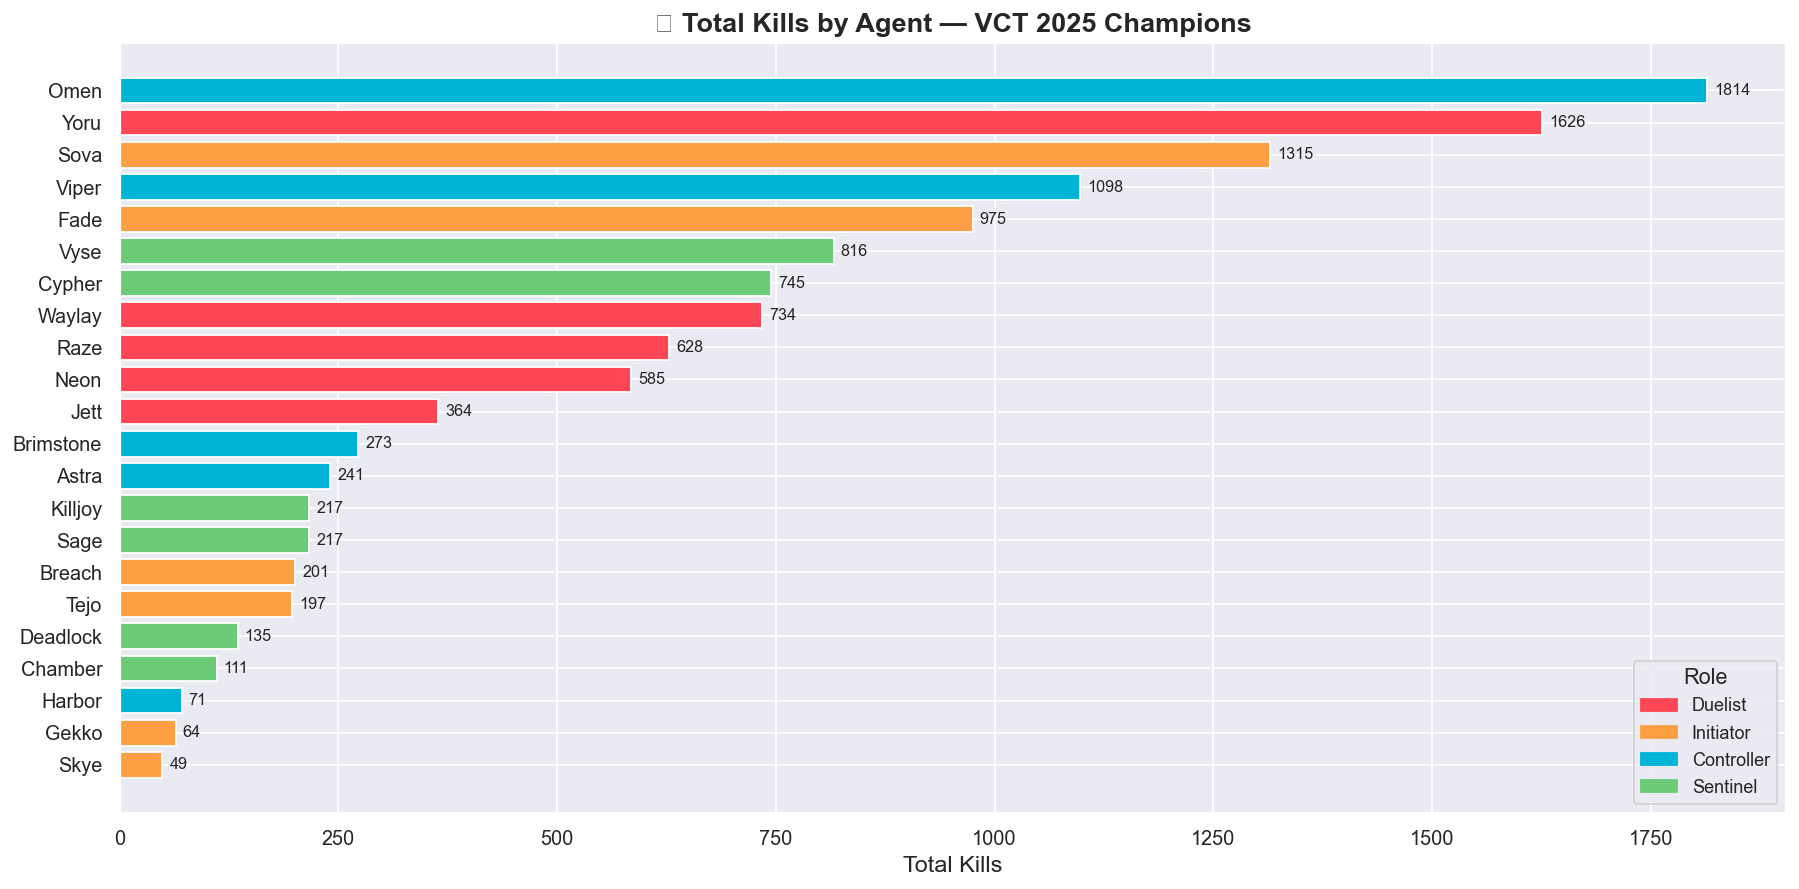

    agent       role  kill
     Omen Controller  1814
     Yoru    Duelist  1626
     Sova  Initiator  1315
    Viper Controller  1098
     Fade  Initiator   975
     Vyse   Sentinel   816
   Cypher   Sentinel   745
   Waylay    Duelist   734
     Raze    Duelist   628
     Neon    Duelist   585
     Jett    Duelist   364
Brimstone Controller   273
    Astra Controller   241
  Killjoy   Sentinel   217
     Sage   Sentinel   217
   Breach  Initiator   201
     Tejo  Initiator   197
 Deadlock   Sentinel   135
  Chamber   Sentinel   111
   Harbor Controller    71
    Gekko  Initiator    64
     Skye  Initiator    49


In [30]:
# ── Total kills grouped by agent ─────────────────────────────
agent_kills = (
    stats.groupby(['agent', 'role'])['kill']
    .sum()
    .reset_index()
    .sort_values('kill', ascending=False)
)

# Role colour palette
ROLE_COLORS = {
    'Duelist':    '#FF4655',
    'Initiator':  '#FF9F43',
    'Controller': '#00B4D8',
    'Sentinel':   '#6BCB77',
}
colors = agent_kills['role'].map(ROLE_COLORS).fillna('#AAAAAA')

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(agent_kills['agent'], agent_kills['kill'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Total Kills', fontsize=13)
ax.set_title('🔫 Total Kills by Agent — VCT 2025 Champions', fontsize=15, fontweight='bold')

# Annotate values
for bar, val in zip(bars, agent_kills['kill']):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            str(int(val)), va='center', fontsize=9)

# Legend
legend_patches = [mpatches.Patch(color=c, label=r) for r, c in ROLE_COLORS.items()]
ax.legend(handles=legend_patches, title='Role', loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('agent_kills.png', bbox_inches='tight')
plt.show()
print(agent_kills.to_string(index=False))

---
## 🏆 5. Top 20 Players by Total Kills

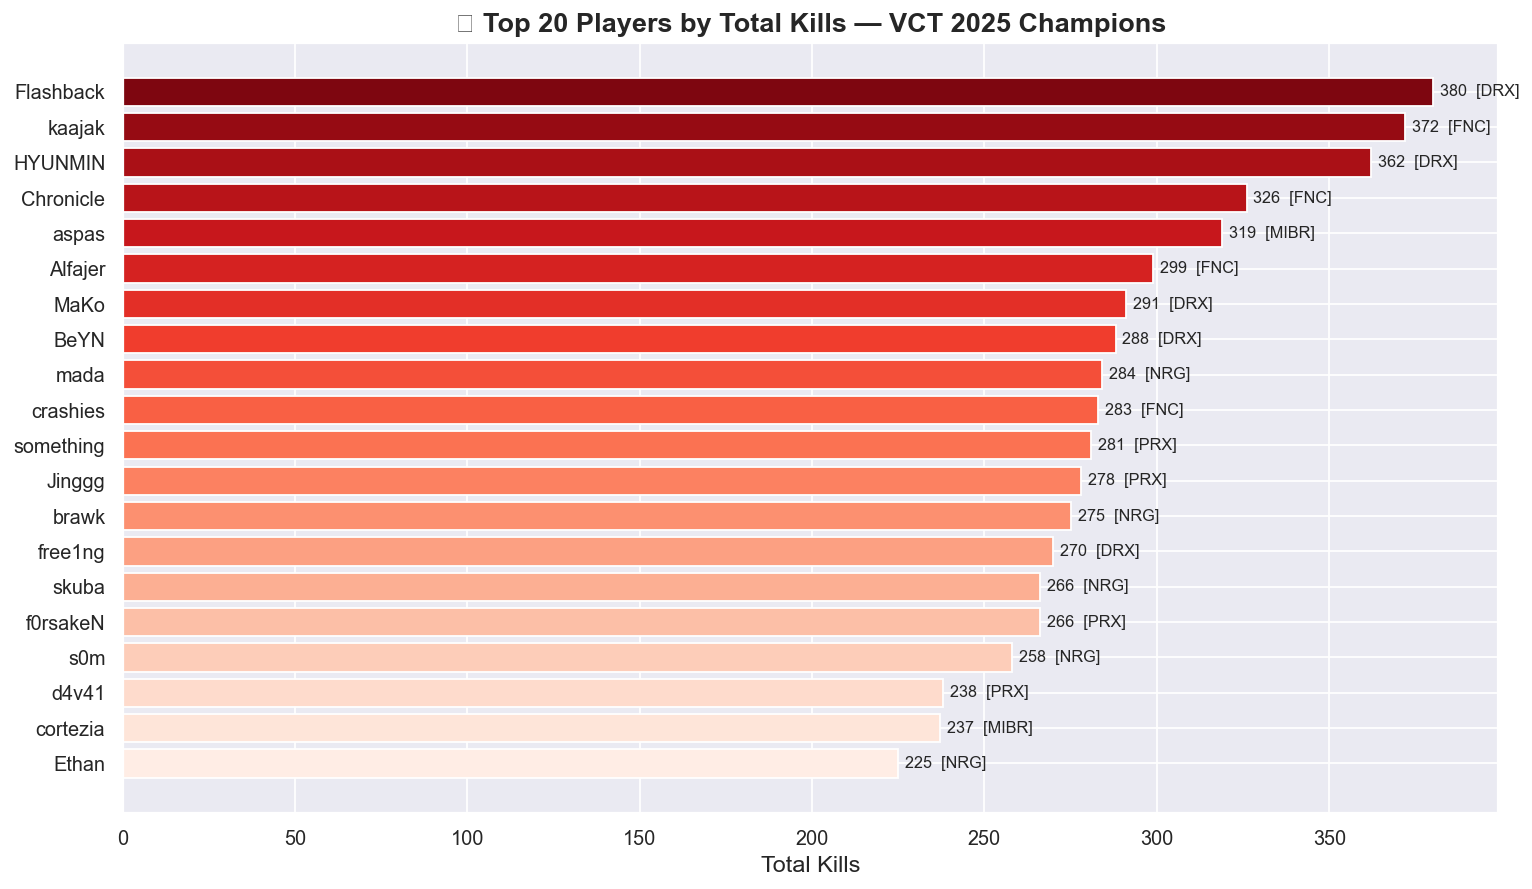


Top 10 Players:
   player team_name  kill
Flashback       DRX   380
   kaajak       FNC   372
  HYUNMIN       DRX   362
Chronicle       FNC   326
    aspas      MIBR   319
  Alfajer       FNC   299
     MaKo       DRX   291
     BeYN       DRX   288
     mada       NRG   284
 crashies       FNC   283


In [31]:
player_kills = (
    stats.groupby(['player', 'team_name'])['kill']
    .sum()
    .reset_index()
    .sort_values('kill', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 7))
palette = sns.color_palette('Reds_r', n_colors=len(player_kills))
bars = ax.barh(player_kills['player'], player_kills['kill'], color=palette)
ax.invert_yaxis()
ax.set_xlabel('Total Kills', fontsize=13)
ax.set_title('🏆 Top 20 Players by Total Kills — VCT 2025 Champions', fontsize=15, fontweight='bold')

for bar, (_, row) in zip(bars, player_kills.iterrows()):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f"{int(row['kill'])}  [{row['team_name']}]", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_player_kills.png', bbox_inches='tight')
plt.show()
print('\nTop 10 Players:')
print(player_kills.head(10).to_string(index=False))

---
## 🎯 6. Clutch Performance (1vX Situations)

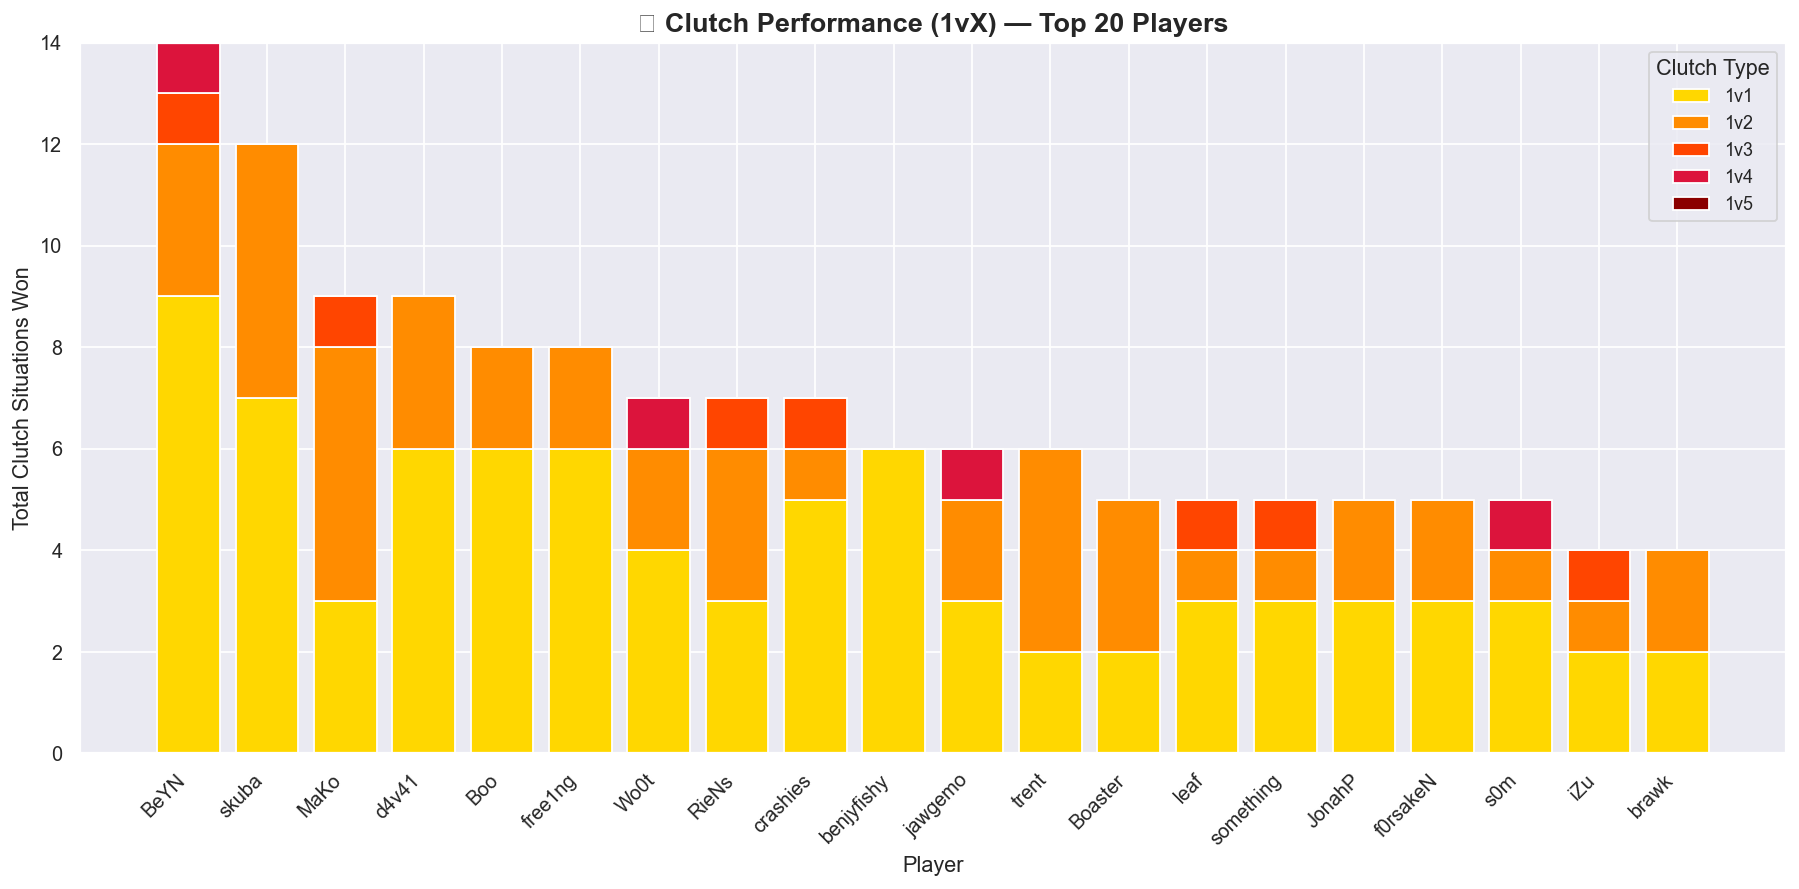

Top 10 Clutch Players:
    player  1v1  1v2  1v3  1v4  1v5  total_clutch
      BeYN    9    3    1    1    0            14
     skuba    7    5    0    0    0            12
      MaKo    3    5    1    0    0             9
     d4v41    6    3    0    0    0             9
       Boo    6    2    0    0    0             8
   free1ng    6    2    0    0    0             8
      Wo0t    4    2    0    1    0             7
     RieNs    3    3    1    0    0             7
  crashies    5    1    1    0    0             7
benjyfishy    6    0    0    0    0             6


In [32]:
# ── Sum up all clutch types per player ───────────────────────
clutch_cols = ['1v1', '1v2', '1v3', '1v4', '1v5']
ck_player = counter_kill.groupby('player')[clutch_cols].sum().reset_index()
ck_player['total_clutch'] = ck_player[clutch_cols].sum(axis=1)
ck_player = ck_player.sort_values('total_clutch', ascending=False).head(20)

# Stacked bar chart
clutch_palette = ['#FFD700', '#FF8C00', '#FF4500', '#DC143C', '#8B0000']

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(ck_player))
for col, color in zip(clutch_cols, clutch_palette):
    vals = ck_player[col].values
    ax.bar(ck_player['player'], vals, bottom=bottom, color=color, label=col)
    bottom += vals

ax.set_title('🎯 Clutch Performance (1vX) — Top 20 Players', fontsize=15, fontweight='bold')
ax.set_xlabel('Player', fontsize=12)
ax.set_ylabel('Total Clutch Situations Won', fontsize=12)
ax.legend(title='Clutch Type', fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('clutch_performance.png', bbox_inches='tight')
plt.show()
print('Top 10 Clutch Players:')
print(ck_player[['player', '1v1', '1v2', '1v3', '1v4', '1v5', 'total_clutch']].head(10).to_string(index=False))

---
## 🧑‍💻 7. Most Used Agents by Players

In [33]:
agent_usage = (
    stats.groupby(['agent', 'role'])['player']
    .count()
    .reset_index()
    .rename(columns={'player': 'picks'})
    .sort_values('picks', ascending=False)
)

fig = px.bar(
    agent_usage,
    x='agent', y='picks',
    color='role',
    color_discrete_map=ROLE_COLORS,
    title='🧑‍💻 Most Picked Agents in VCT 2025 Champions',
    labels={'picks': 'Total Picks', 'agent': 'Agent', 'role': 'Role'},
    text='picks',
    height=500
)
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-40)
fig.show()
print(agent_usage.head(10).to_string(index=False))

 agent       role  picks
  Omen Controller    282
  Sova  Initiator    188
  Yoru    Duelist    186
 Viper Controller    152
  Fade  Initiator    150
Cypher   Sentinel    106
  Vyse   Sentinel    106
Waylay    Duelist     90
  Neon    Duelist     78
  Raze    Duelist     76


---
## 📈 8. Agent Win Rate

In [34]:
# ── Join stats with score to get win/loss per game ───────────
# Build a lookup: (match_id, game_id, team_id) → win/loss
score_long = pd.concat([
    score[['match_id', 'game_id', 'team_1_id', 'team_1_wl']].rename(
        columns={'team_1_id': 'team_id', 'team_1_wl': 'result'}),
    score[['match_id', 'game_id', 'team_2_id', 'team_2_wl']].rename(
        columns={'team_2_id': 'team_id', 'team_2_wl': 'result'})
], ignore_index=True)

stats_w = stats.merge(score_long, on=['match_id', 'game_id', 'team_id'], how='left')
stats_w['win'] = (stats_w['result'] == 'win').astype(int)

agent_winrate = (
    stats_w.groupby(['agent', 'role'])
    .agg(games=('win', 'count'), wins=('win', 'sum'))
    .reset_index()
)
agent_winrate['win_rate'] = (agent_winrate['wins'] / agent_winrate['games'] * 100).round(1)
agent_winrate = agent_winrate[agent_winrate['games'] >= 5].sort_values('win_rate', ascending=False)

fig = px.bar(
    agent_winrate,
    x='agent', y='win_rate',
    color='role',
    color_discrete_map=ROLE_COLORS,
    title='📈 Agent Win Rate (min 5 games) — VCT 2025 Champions',
    labels={'win_rate': 'Win Rate (%)', 'agent': 'Agent'},
    text='win_rate',
    height=500
)
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.add_hline(y=50, line_dash='dash', line_color='white', annotation_text='50% baseline')
fig.update_layout(xaxis_tickangle=-40)
fig.show()
print('Top 10 Agents by Win Rate:')
print(agent_winrate[['agent', 'role', 'games', 'win_rate']].head(10).to_string(index=False))

Top 10 Agents by Win Rate:
    agent       role  games  win_rate
   Harbor Controller     10      80.0
     Sage   Sentinel     26      69.2
     Sova  Initiator    188      62.8
  Killjoy   Sentinel     32      62.5
    Viper Controller    152      61.8
Brimstone Controller     34      58.8
     Raze    Duelist     76      57.9
   Waylay    Duelist     90      57.8
     Yoru    Duelist    186      57.0
     Omen Controller    282      55.3


---
## 💥 9. Highest Kills & Headshot % Combined

In [35]:
# ── Per player: aggregate kills and mean HS% ─────────────────
player_hs = (
    stats.groupby('player')
    .agg(total_kills=('kill', 'sum'), avg_hs=('hs_pct', 'mean'), games=('game_id', 'nunique'))
    .reset_index()
    .sort_values('total_kills', ascending=False)
)
player_hs['avg_hs'] = player_hs['avg_hs'].round(1)

# Bubble chart: x=kills, y=HS%, size=games
top50 = player_hs.head(50)

fig = px.scatter(
    top50,
    x='total_kills', y='avg_hs',
    size='games', text='player',
    color='avg_hs',
    color_continuous_scale='RdYlGn',
    title='💥 Kills vs Headshot % — Top 50 Players (bubble = games played)',
    labels={'total_kills': 'Total Kills', 'avg_hs': 'Avg HS%', 'games': 'Games'},
    hover_data={'player': True, 'total_kills': True, 'avg_hs': True, 'games': True},
    height=600
)
fig.update_traces(textposition='top center', textfont_size=8)
fig.show()

print('Top 15 Players by Kills + HS%:')
print(player_hs.head(15).to_string(index=False))

Top 15 Players by Kills + HS%:
   player  total_kills  avg_hs  games
Flashback          380    24.6     22
   kaajak          372    35.3     22
  HYUNMIN          362    39.9     22
Chronicle          326    27.9     22
    aspas          319    30.3     15
  Alfajer          299    34.2     19
     MaKo          291    26.9     22
     BeYN          288    29.4     22
     mada          284    27.0     17
 crashies          283    35.3     22
something          281    25.4     16
   Jinggg          278    23.4     16
    brawk          275    18.3     17
  free1ng          270    37.2     22
    skuba          266    32.2     17


---
## 🔀 10. Multi-Agent Players — Best Agent by Kills & HS%

In [36]:
# ── Players who played 2+ different agents ───────────────────
player_agent_stats = (
    stats.groupby(['player', 'agent', 'role'])
    .agg(kills=('kill', 'sum'), avg_hs=('hs_pct', 'mean'), games=('game_id', 'nunique'))
    .reset_index()
)
player_agent_stats['avg_hs'] = player_agent_stats['avg_hs'].round(1)

# Count unique agents per player
agent_counts = player_agent_stats.groupby('player')['agent'].nunique().reset_index()
agent_counts.columns = ['player', 'agents_played']
multi_players = agent_counts[agent_counts['agents_played'] >= 2]['player'].tolist()

multi_df = player_agent_stats[player_agent_stats['player'].isin(multi_players)].copy()

# Best agent per player by kills
best_by_kills = (
    multi_df.loc[multi_df.groupby('player')['kills'].idxmax()]
    .sort_values('kills', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Best agent per player by HS%
best_by_hs = (
    multi_df.loc[multi_df.groupby('player')['avg_hs'].idxmax()]
    .sort_values('avg_hs', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print(f'Players who used 2+ agents: {len(multi_players)}')
print('\n🔝 Best Agent by KILLS (for multi-agent players):')
print(best_by_kills[['player', 'agent', 'role', 'kills', 'avg_hs', 'games']].to_string(index=False))

print('\n🎯 Best Agent by HS% (for multi-agent players):')
print(best_by_hs[['player', 'agent', 'role', 'avg_hs', 'kills', 'games']].to_string(index=False))

Players who used 2+ agents: 77

🔝 Best Agent by KILLS (for multi-agent players):
   player  agent       role  kills  avg_hs  games
  HYUNMIN Waylay    Duelist    343    39.9     21
Flashback   Yoru    Duelist    337    24.8     19
   kaajak   Yoru    Duelist    242    35.9     14
something   Yoru    Duelist    241    24.2     14
     MaKo   Omen Controller    231    26.9     18
    brawk   Sova  Initiator    216    19.7     14
  jawgemo   Yoru    Duelist    205    28.9     11
 f0rsakeN   Omen Controller    198    31.4     12
   Jinggg   Raze    Duelist    198    19.3     11
    Verno   Sova  Initiator    196    29.7     13
Chronicle  Viper Controller    173    29.6     12
    d4v41   Vyse   Sentinel    170    26.3     11
 crashies   Sova  Initiator    165    30.8     12
      s0m   Omen Controller    161    23.5     10
     BeYN   Sova  Initiator    152    28.2     11
    trent   Tejo  Initiator    139    33.6     10
 westside Cypher   Sentinel    133    42.4     10
    valyn   Omen Co

In [37]:
# ── Visualise multi-agent performance per player ─────────────
# Pick top 10 multi-agent players by total kills
top_multi = (
    multi_df.groupby('player')['kills'].sum()
    .sort_values(ascending=False)
    .head(10).index.tolist()
)

subset = multi_df[multi_df['player'].isin(top_multi)]

fig = px.bar(
    subset,
    x='player', y='kills',
    color='agent',
    barmode='group',
    title='🔀 Multi-Agent Players — Kills per Agent (Top 10 Players)',
    labels={'kills': 'Total Kills', 'player': 'Player'},
    height=500,
    hover_data={'avg_hs': True, 'games': True}
)
fig.update_layout(xaxis_tickangle=-30)
fig.show()

In [38]:
# ── HS% comparison across agents for multi-agent players ─────
fig = px.scatter(
    subset,
    x='kills', y='avg_hs',
    color='agent',
    symbol='player',
    size='games',
    hover_data={'player': True, 'agent': True, 'kills': True, 'avg_hs': True},
    title='🎯 Multi-Agent Players — HS% vs Kills per Agent',
    labels={'kills': 'Total Kills', 'avg_hs': 'Avg HS%'},
    height=500
)
fig.show()

---
## 🃏 11. Agent Role Breakdown

In [39]:
role_stats = (
    stats.groupby('role')
    .agg(
        total_kills=('kill', 'sum'),
        avg_hs=('hs_pct', 'mean'),
        avg_acs=('acs', 'mean'),
        avg_rating=('rating', 'mean'),
        picks=('player', 'count')
    )
    .reset_index()
    .sort_values('total_kills', ascending=False)
)
role_stats = role_stats.round(2)

# ✅ FIX: specify specs so position (2,2) accepts 'domain' type (Pie)
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Total Kills by Role', 'Avg HS% by Role',
                    'Avg ACS by Role', 'Agent Picks by Role'),
    specs=[[{'type': 'xy'},     {'type': 'xy'}],
           [{'type': 'xy'},     {'type': 'domain'}]]   # <-- key fix
)

role_colors = [ROLE_COLORS.get(r, '#AAAAAA') for r in role_stats['role']]

fig.add_trace(go.Bar(x=role_stats['role'], y=role_stats['total_kills'],
    marker_color=role_colors, name='Kills'), row=1, col=1)
fig.add_trace(go.Bar(x=role_stats['role'], y=role_stats['avg_hs'],
    marker_color=role_colors, name='HS%'), row=1, col=2)
fig.add_trace(go.Bar(x=role_stats['role'], y=role_stats['avg_acs'],
    marker_color=role_colors, name='ACS'), row=2, col=1)
fig.add_trace(go.Pie(labels=role_stats['role'], values=role_stats['picks'],
    marker_colors=role_colors, name='Picks'), row=2, col=2)

fig.update_layout(height=700, title_text='🃏 Agent Role Breakdown — VCT 2025 Champions',
                  showlegend=False)
fig.show()
print(role_stats.to_string(index=False))

      role  total_kills  avg_hs  avg_acs  avg_rating  picks
   Duelist         3937   29.31   216.63        1.02    470
Controller         3497   29.34   180.10        0.97    520
 Initiator         2801   29.62   182.72        0.99    418
  Sentinel         2241   32.12   190.18        0.99    302


---
## 🌐 12. Interactive Dashboard

In [40]:
# ══════════════════════════════════════════════════════════════
# INTERACTIVE DASHBOARD — Kills, HS%, Agent Role, Best Players
# ══════════════════════════════════════════════════════════════

from IPython.display import display

# ── Widget controls ──────────────────────────────────────────
role_options   = ['All'] + sorted(stats['role'].dropna().unique().tolist())
agent_options  = ['All'] + sorted(stats['agent'].dropna().unique().tolist())
metric_options = ['total_kills', 'avg_hs', 'avg_acs', 'avg_rating']
metric_labels  = {'total_kills': 'Total Kills', 'avg_hs': 'Avg HS%',
                  'avg_acs': 'Avg ACS', 'avg_rating': 'Avg Rating'}

role_dd   = widgets.Dropdown(options=role_options,   value='All', description='Role:')
agent_dd  = widgets.Dropdown(options=agent_options,  value='All', description='Agent:')
metric_dd = widgets.Dropdown(options=metric_options, value='total_kills',
                              description='Metric:', style={'description_width': 'initial'})
topn_sl   = widgets.IntSlider(value=15, min=5, max=30, step=1,
                              description='Top N:', style={'description_width': 'initial'})

out = widgets.Output()

def update_dashboard(role, agent, metric, topn):
    out.clear_output(wait=True)
    with out:
        df = stats.copy()
        if role  != 'All': df = df[df['role']  == role]
        if agent != 'All': df = df[df['agent'] == agent]

        agg = (
            df.groupby(['player', 'agent', 'role', 'team_name'])
            .agg(total_kills=('kill','sum'), avg_hs=('hs_pct','mean'),
                 avg_acs=('acs','mean'), avg_rating=('rating','mean'),
                 games=('game_id','nunique'))
            .reset_index().round(2)
            .sort_values(metric, ascending=False)
            .head(topn)
        )

        title = f'🎮 Top {topn} Players by {metric_labels[metric]}'
        if role  != 'All': title += f' | Role: {role}'
        if agent != 'All': title += f' | Agent: {agent}'

        fig = px.bar(
            agg, x='player', y=metric,
            color='agent',
            title=title,
            hover_data={'total_kills':True,'avg_hs':True,'avg_acs':True,
                        'avg_rating':True,'team_name':True,'games':True},
            labels={metric: metric_labels[metric], 'player': 'Player'},
            height=480
        )
        fig.update_layout(xaxis_tickangle=-35)
        fig.show()

        # Scatter: kills vs HS%
        fig2 = px.scatter(
            agg, x='total_kills', y='avg_hs',
            color='role', size='games', text='player',
            color_discrete_map=ROLE_COLORS,
            title='Kills vs HS% (bubble = games played)',
            labels={'total_kills':'Total Kills','avg_hs':'Avg HS%'},
            height=420
        )
        fig2.update_traces(textposition='top center', textfont_size=8)
        fig2.show()

interact_out = widgets.interactive_output(
    update_dashboard,
    {'role': role_dd, 'agent': agent_dd, 'metric': metric_dd, 'topn': topn_sl}
)

header = widgets.HTML('<h3 style="color:#FF4655">🔴 VCT 2025 Champions Interactive Dashboard</h3>')
controls = widgets.HBox([role_dd, agent_dd, metric_dd, topn_sl])
display(header, controls, out)
update_dashboard('All', 'All', 'total_kills', 15)

HTML(value='<h3 style="color:#FF4655">🔴 VCT 2025 Champions Interactive Dashboard</h3>')

Output()

---
## 🕸️ 13. Agent Performance Radar Chart

In [41]:
# ── Radar per role ────────────────────────────────────────────
radar_metrics = ['avg_kills', 'avg_hs', 'avg_acs', 'avg_assist', 'avg_adr']

role_radar = (
    stats.groupby('role')
    .agg(avg_kills=('kill','mean'), avg_hs=('hs_pct','mean'),
         avg_acs=('acs','mean'), avg_assist=('assist','mean'),
         avg_adr=('adr','mean'))
    .reset_index().round(2)
)

# Normalize 0-1
for col in radar_metrics:
    col_max = role_radar[col].max()
    role_radar[f'{col}_n'] = role_radar[col] / col_max if col_max > 0 else 0

norm_cols = [f'{m}_n' for m in radar_metrics]
labels    = ['Kills', 'HS%', 'ACS', 'Assists', 'ADR']

fig = go.Figure()
for _, row in role_radar.iterrows():
    vals = list(row[norm_cols]) + [row[norm_cols[0]]]   # close the loop
    lbl  = labels + [labels[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=lbl, fill='toself',
        name=row['role'],
        line_color=ROLE_COLORS.get(row['role'], '#AAAAAA')
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='🕸️ Agent Role Performance Radar (normalised)',
    height=520
)
fig.show()

---
## 📊 14. Heatmap — Agent × Player Kills Matrix

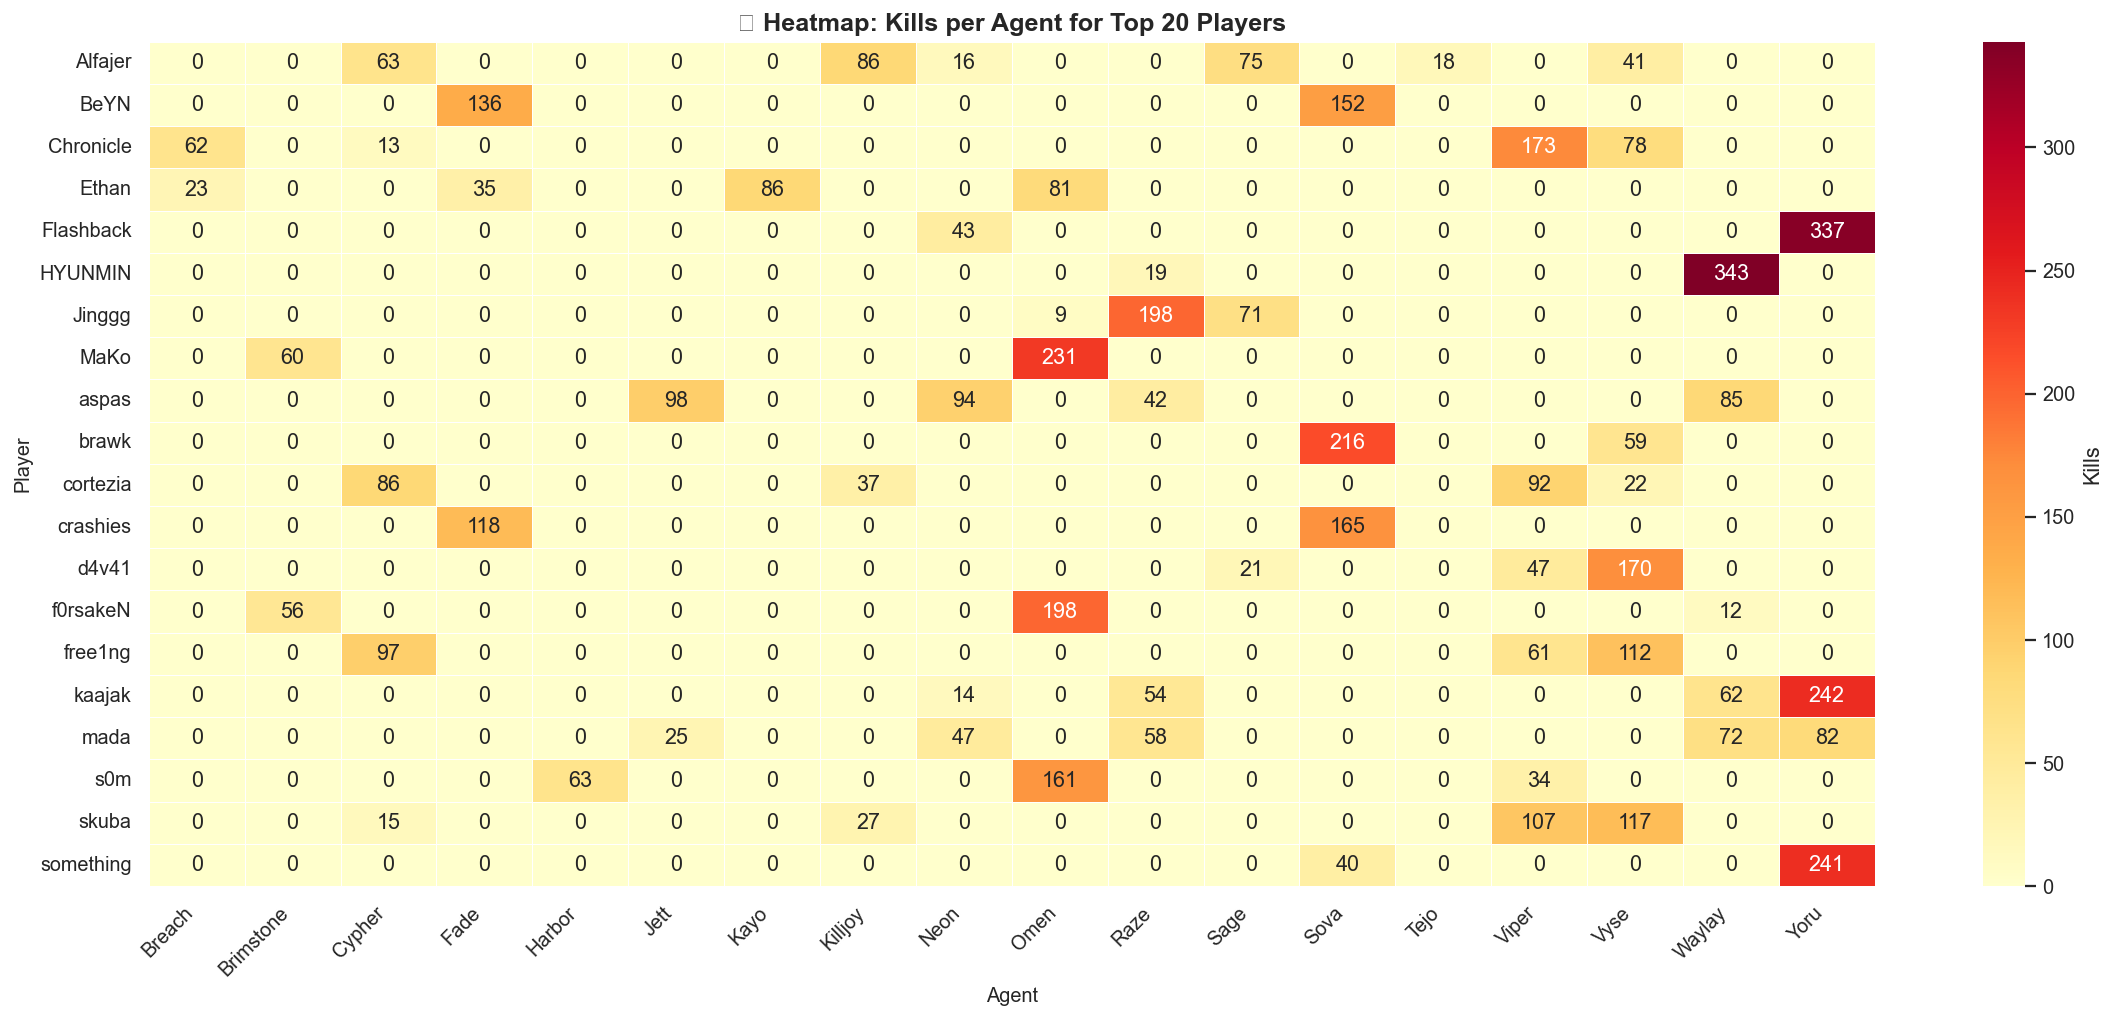

In [42]:
# ── Top 20 players × all agents ──────────────────────────────
top20_players = (
    stats.groupby('player')['kill'].sum()
    .nlargest(20).index.tolist()
)

heat_data = (
    stats[stats['player'].isin(top20_players)]
    .groupby(['player', 'agent'])['kill']
    .sum().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    heat_data, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Kills'}
)
ax.set_title('📊 Heatmap: Kills per Agent for Top 20 Players', fontsize=14, fontweight='bold')
ax.set_xlabel('Agent', fontsize=11)
ax.set_ylabel('Player', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('agent_player_heatmap.png', bbox_inches='tight')
plt.show()

---
## 📋 15. Summary Table — All Key Metrics

In [43]:
summary = (
    stats.groupby(['agent', 'role'])
    .agg(
        picks=('player', 'count'),
        total_kills=('kill', 'sum'),
        avg_kills_per_map=('kill', 'mean'),
        avg_hs=('hs_pct', 'mean'),
        avg_acs=('acs', 'mean'),
        avg_adr=('adr', 'mean'),
        avg_rating=('rating', 'mean')
    )
    .reset_index()
    .round(2)
    .sort_values('total_kills', ascending=False)
)

# Merge win rate
summary = summary.merge(
    agent_winrate[['agent', 'win_rate']],
    on='agent', how='left'
)

display(HTML('<h3>📋 Complete Agent Summary Table</h3>'))
display(summary.style
    .background_gradient(subset=['total_kills', 'avg_hs', 'win_rate'], cmap='RdYlGn')
    .format({'avg_kills_per_map': '{:.1f}', 'avg_hs': '{:.1f}%',
             'avg_acs': '{:.0f}', 'avg_adr': '{:.0f}', 'avg_rating': '{:.2f}',
             'win_rate': '{:.1f}%'})
)

# Save to CSV
summary.to_csv('vct2025_agent_summary.csv', index=False)
print('✅ Saved to vct2025_agent_summary.csv')

,agent,role,picks,total_kills,avg_kills_per_map,avg_hs,avg_acs,avg_adr,avg_rating,win_rate
0,Omen,Controller,282,1814,6.4,28.8%,171,110,0.94,55.3%
1,Yoru,Duelist,186,1626,8.7,28.9%,219,139,1.05,57.0%
2,Sova,Initiator,188,1315,7.0,28.1%,194,131,1.06,62.8%
3,Viper,Controller,152,1098,7.2,29.4%,200,132,1.04,61.8%
4,Fade,Initiator,150,975,6.5,31.0%,175,113,0.94,49.3%
5,Vyse,Sentinel,106,816,7.7,30.2%,190,125,0.97,52.8%
6,Cypher,Sentinel,106,745,7.0,35.2%,184,120,0.99,50.9%
7,Waylay,Duelist,90,734,8.2,35.0%,204,131,0.95,57.8%
8,Raze,Duelist,76,628,8.3,22.1%,228,150,1.06,57.9%
9,Neon,Duelist,78,585,7.5,29.9%,204,133,0.91,43.6%


✅ Saved to vct2025_agent_summary.csv


---
## 🏅 16. Final Key Insights

In [44]:
top_killer     = player_kills.iloc[0]
top_clutcher   = ck_player.iloc[0]
top_agent_k    = agent_kills.iloc[0]
top_agent_wr   = agent_winrate.iloc[0]
most_picked    = agent_usage.iloc[0]
best_hs_player = player_hs.sort_values('avg_hs', ascending=False).iloc[0]

insights = f"""

         🏆 VCT 2025 CHAMPIONS — KEY INSIGHTS                  

 🔫 Most Kills (Player)  : {top_killer['player']:<20} {int(top_killer['kill']):>5} kills  
 🔫 Most Kills (Agent)   : {top_agent_k['agent']:<20} {int(top_agent_k['kill']):>5} kills  
 🎯 Best HS% Player      : {best_hs_player['player']:<20} {best_hs_player['avg_hs']:>5.1f}%       
 🥊 Top Clutch Player    : {top_clutcher['player']:<20} {int(top_clutcher['total_clutch']):>5} clutches
 📈 Highest Win Rate     : {top_agent_wr['agent']:<20} {top_agent_wr['win_rate']:>5.1f}%       
 🧑‍💻 Most Picked Agent    : {most_picked['agent']:<20} {int(most_picked['picks']):>5} picks 

"""
print(insights)



         🏆 VCT 2025 CHAMPIONS — KEY INSIGHTS                  

 🔫 Most Kills (Player)  : Flashback              380 kills  
 🔫 Most Kills (Agent)   : Omen                  1814 kills  
 🎯 Best HS% Player      : Kushy                 41.4%       
 🥊 Top Clutch Player    : BeYN                    14 clutches
 📈 Highest Win Rate     : Harbor                80.0%       
 🧑‍💻 Most Picked Agent    : Omen                   282 picks 


